## SCRIPTS FOR ANALYSIS

### SCRIPTS FOR FULL DATASET ANALYSIS

Script to search the entire dataset for missing values – gaps_in_all_data.py

In [ ]:
import pandas as pd

file_path = r'train.csv'
data = pd.read_csv(file_path)

def count_true_gaps(df):
    # Create a copy to make non-invasive modifications
    temp_df = df.copy()

    # Ignore NULLs in ORIGIN_CALL when CALL_TYPE ≠ 'A'
    temp_df.loc[temp_df['CALL_TYPE'] != 'A', 'ORIGIN_CALL'] = temp_df['ORIGIN_CALL'].fillna(0)
    # Ignore NULLs in ORIGIN_STAND when CALL_TYPE ≠ 'B'
    temp_df.loc[temp_df['CALL_TYPE'] != 'B', 'ORIGIN_STAND'] = temp_df['ORIGIN_STAND'].fillna(0)

    # Counting true data gaps
    total_gaps = temp_df.isna().sum().sum()  # Total number of data gaps after filtering
    total_values = temp_df.size  # Total number of values
    gap_percentage = (total_gaps / total_values) * 100

    print(f"Total number of data gaps: {total_gaps}")
    print(f"Percentage of data gaps: {gap_percentage:.2f}%")

count_true_gaps(data)

Total number of data gaps: 11302
Percentage of data gaps: 0.07%


Script to search individual columns for missing values – gaps_in_columns.py

In [ ]:
import pandas as pd

file_path = r'train.csv'
data = pd.read_csv(file_path)

def columnwise_true_gap_statistics(df):
    temp_df = df.copy()

    # Ignore NULLs in ORIGIN_CALL when CALL_TYPE ≠ 'A'
    temp_df.loc[temp_df['CALL_TYPE'] != 'A', 'ORIGIN_CALL'] = temp_df['ORIGIN_CALL'].fillna(0)
    # Ignore NULLs in ORIGIN_STAND when CALL_TYPE ≠ 'B'
    temp_df.loc[temp_df['CALL_TYPE'] != 'B', 'ORIGIN_STAND'] = temp_df['ORIGIN_STAND'].fillna(0)

    # Number of data gaps in each column
    column_gaps = temp_df.isna().sum()
    column_gaps_percentage = (column_gaps / len(temp_df)) * 100  # Percentage of gaps

    # Results table
    gaps_df = pd.DataFrame({
        'Number of gaps': column_gaps,
        'Percentage of gaps': column_gaps_percentage
    })

    print(gaps_df)

columnwise_true_gap_statistics(data)

              Number of gaps  Percentage of gaps
TRIP_ID                    0            0.000000
CALL_TYPE                  0            0.000000
ORIGIN_CALL                0            0.000000
ORIGIN_STAND           11302            0.660677
TAXI_ID                    0            0.000000
TIMESTAMP                  0            0.000000
DAY_TYPE                   0            0.000000
MISSING_DATA               0            0.000000
POLYLINE                   0            0.000000


Script to export a list of records with missing values (without the POLYLINE column) – gaps_in_columns_to_CSV.py

In [ ]:
import pandas as pd

# Load the data
file_path = r'train.csv'
data = pd.read_csv(file_path)

# Create a copy of the data to apply exceptions for missing data in ORIGIN_CALL and ORIGIN_STAND
temp_df = data.copy()

# Ignore NULLs in ORIGIN_CALL when CALL_TYPE ≠ 'A'
temp_df.loc[temp_df['CALL_TYPE'] != 'A', 'ORIGIN_CALL'] = temp_df['ORIGIN_CALL'].fillna(0)
# Ignore NULLs in ORIGIN_STAND when CALL_TYPE ≠ 'B'
temp_df.loc[temp_df['CALL_TYPE'] != 'B', 'ORIGIN_STAND'] = temp_df['ORIGIN_STAND'].fillna(0)

# Filter rows that contain at least one missing value
rows_with_gaps = data[temp_df.isna().any(axis=1)]

# Remove the POLYLINE column
rows_with_gaps = rows_with_gaps.drop(columns=['POLYLINE'])

# Path to save the file
output_path = r'gaps_in_columns_list.csv'

# Export to CSV file
rows_with_gaps.to_csv(output_path, index=False)

print(f"Rows containing missing data (without the POLYLINE column) have been saved to the file: {output_path}")


Script to export a list of records without missing values – remove_gaps.py

In [ ]:
import pandas as pd

# Defining file paths
train_file_path = r"train.csv"
missing_data_file_path = r"gaps_in_columns_list.csv"
output_file_path = r"train_no_gaps.csv"

# Loading CSV files into DataFrames
train_df = pd.read_csv(train_file_path)
missing_data_df = pd.read_csv(missing_data_file_path)

# Removing records from train_df that have TRIP_IDs present in missing_data_df
cleaned_train_df = train_df[~train_df['TRIP_ID'].isin(missing_data_df['TRIP_ID'])]

# Saving the new DataFrame to a CSV file
cleaned_train_df.to_csv(output_file_path, index=False)

print("Records have been removed and saved as train_no_gaps.csv.")

### SCRIPTS FOR ANALYZING INDIVIDUAL COLUMNS

script for analysis – analize_CALL_TYPE.py

In [ ]:
import pandas as pd

# Load data from the CSV file
file_path = r'train_no_gaps.csv'
data = pd.read_csv(file_path)

# Check if the 'CALL_TYPE' column exists
if 'CALL_TYPE' in data.columns:
    # Calculate counts and percentages
    call_type_counts = data['CALL_TYPE'].value_counts()
    total_calls = len(data['CALL_TYPE'])
    call_type_percentage = (call_type_counts / total_calls) * 100

    # Create a DataFrame with the results
    analysis_results = pd.DataFrame({
        'Count': call_type_counts,
        'Percentage (%)': call_type_percentage
    }).reset_index().rename(columns={'index': 'CALL_TYPE'})

    # Display the results
    print(analysis_results)
else:
    print("The 'CALL_TYPE' column was not found in the file.")

  CALL_TYPE   Count  Percentage (%)
0         B  806579       47.463469
1         C  528019       31.071492
2         A  364770       21.465039


script for analysis – analize_ORIGIN_CALL.py

In [ ]:
import pandas as pd

# File paths
input_file_path = r'train_no_gaps.csv'
output_file_path = r"ORIGIN_CALL_statistics.csv"

# Load data from train_no_gaps.csv
df = pd.read_csv(input_file_path)

# Remove records with NULL in the ORIGIN_CALL column
df_filtered = df.dropna(subset=['ORIGIN_CALL'])

# Group by ORIGIN_CALL and count the number of occurrences
origin_call_counts = df_filtered['ORIGIN_CALL'].value_counts().reset_index()
origin_call_counts.columns = ['ORIGIN_CALL', 'count']

# Export the results to ORIGIN_CALL_statistics.csv
origin_call_counts.to_csv(output_file_path, index=False)

print("The file ORIGIN_CALL_statistics.csv has been saved.")

The file ORIGIN_CALL_statistics.csv has been saved.


script for drawing charts – figure_ORIGIN_CALL.py

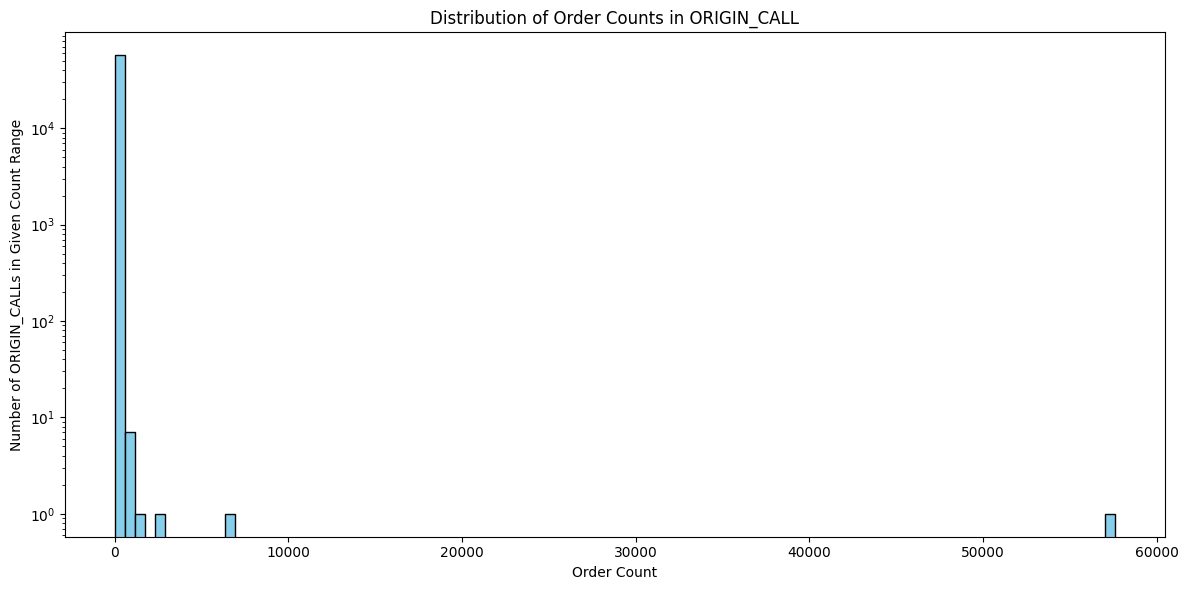

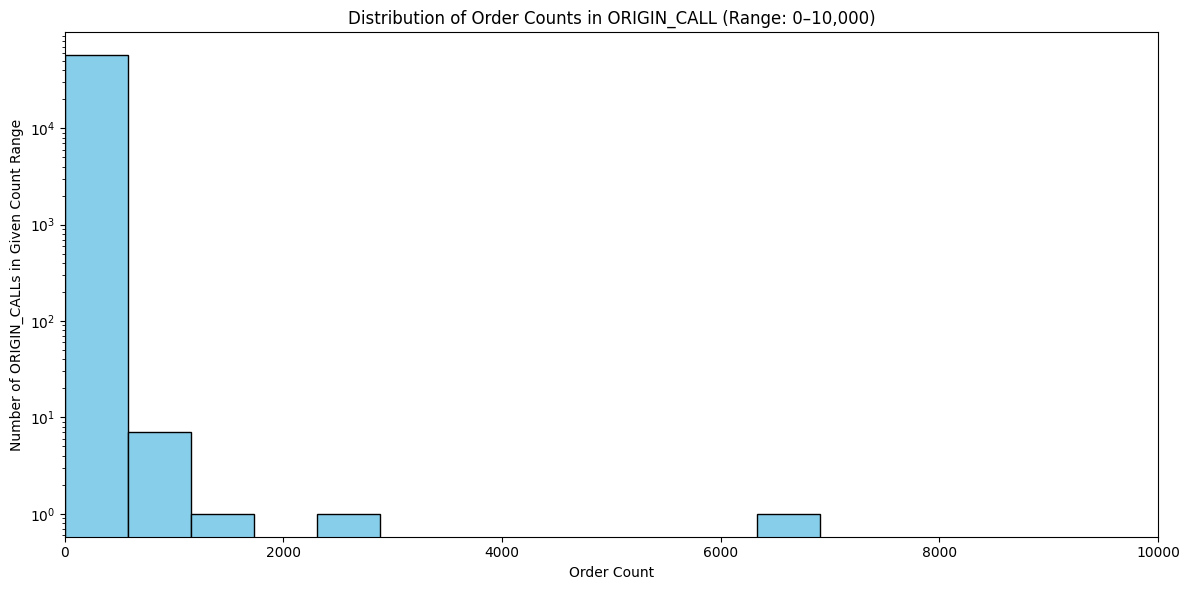

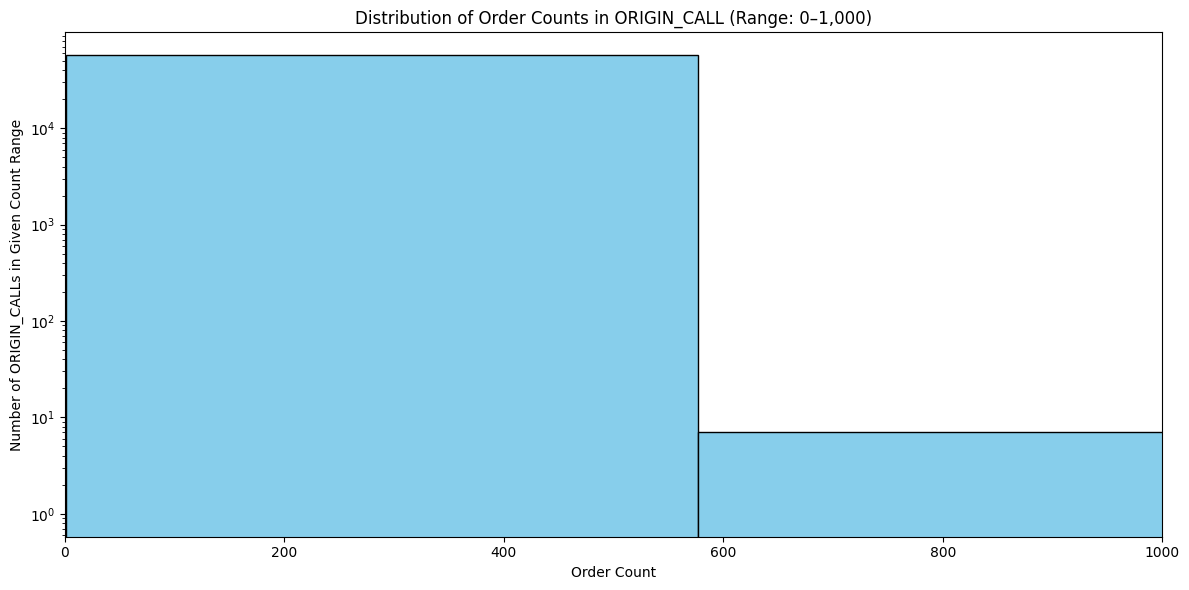

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the ORIGIN_CALL_statistics.csv file
file_path = r"ORIGIN_CALL_statistics.csv"

# Load data from the file
df = pd.read_csv(file_path)

# Draw histogram
plt.figure(figsize=(12, 6))
plt.hist(df['count'], bins=100, color='skyblue', edgecolor='black')  # bins=100 can be adjusted

# Chart settings
plt.title("Distribution of Order Counts in ORIGIN_CALL")
plt.xlabel("Order Count")
plt.ylabel("Number of ORIGIN_CALLs in Given Count Range")
plt.yscale('log') 

# Display the plot
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Path to the ORIGIN_CALL_statistics.csv file
file_path = r"ORIGIN_CALL_statistics.csv"

# Load data from the file
df = pd.read_csv(file_path)

# Draw histogram for the range 0–10,000
plt.figure(figsize=(12, 6))
plt.hist(df['count'], bins=100, color='skyblue', edgecolor='black') 

# Set x-axis range to 0–10,000
plt.xlim(0, 10000)

# Chart settings
plt.title("Distribution of Order Counts in ORIGIN_CALL (Range: 0–10,000)")
plt.xlabel("Order Count")
plt.ylabel("Number of ORIGIN_CALLs in Given Count Range")
plt.yscale('log') 

# Display the plot
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Path to the ORIGIN_CALL_statistics.csv file
file_path = r"ORIGIN_CALL_statistics.csv"

# Load data from the file
df = pd.read_csv(file_path)

# Draw histogram for the range 0–1,000
plt.figure(figsize=(12, 6))
plt.hist(df['count'], bins=100, color='skyblue', edgecolor='black')  

# Set x-axis range to 0–1,000
plt.xlim(0, 1000)

# Chart settings
plt.title("Distribution of Order Counts in ORIGIN_CALL (Range: 0–1,000)")
plt.xlabel("Order Count")
plt.ylabel("Number of ORIGIN_CALLs in Given Count Range")
plt.yscale('log') 

# Display the plot
plt.tight_layout()
plt.show()

script for analysis – analize_ORIGIN_STAND.py

In [ ]:
import pandas as pd

# File paths
input_file_path = r"train_no_gaps.csv"
output_file_path = r"ORIGIN_STAND_statistics.csv"

# Load data from train_no_gaps.csv
df = pd.read_csv(input_file_path)

# Remove records with NULL in the ORIGIN_STAND column
df_filtered = df.dropna(subset=['ORIGIN_STAND'])

# Group by ORIGIN_STAND and count the number of occurrences
origin_call_counts = df_filtered['ORIGIN_STAND'].value_counts().reset_index()
origin_call_counts.columns = ['ORIGIN_STAND', 'count']

# Export the results to ORIGIN_STAND_statistics.csv
origin_call_counts.to_csv(output_file_path, index=False)

print("The file ORIGIN_STAND_statistics.csv has been saved.")

The file ORIGIN_STAND_statistics.csv has been saved.


script for drawing charts – figure_ORIGIN_STAND.py

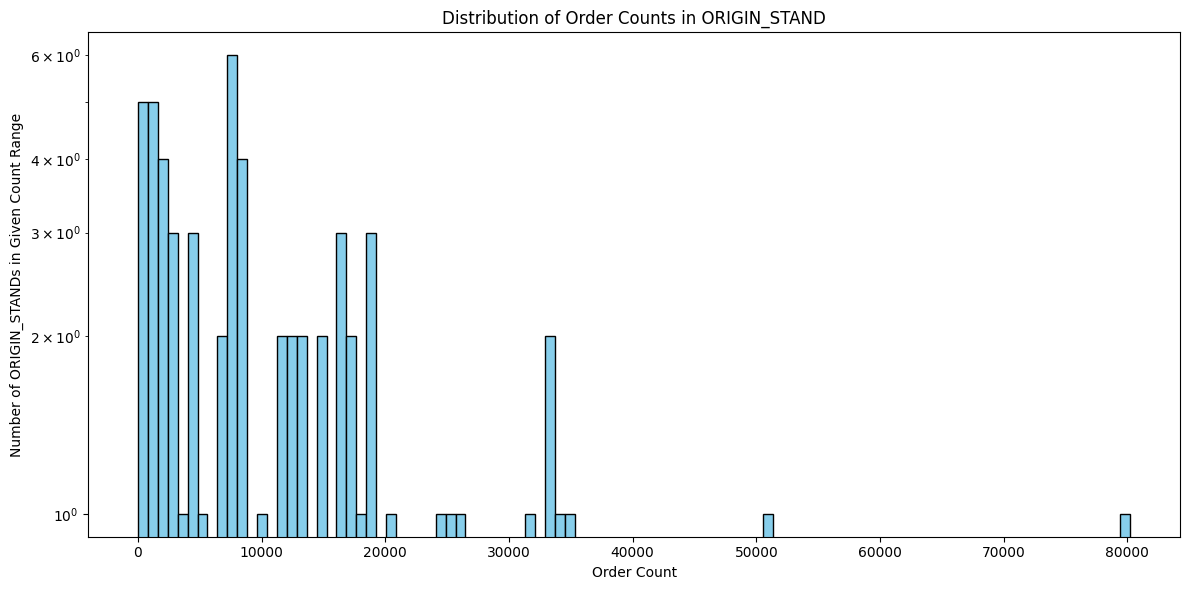

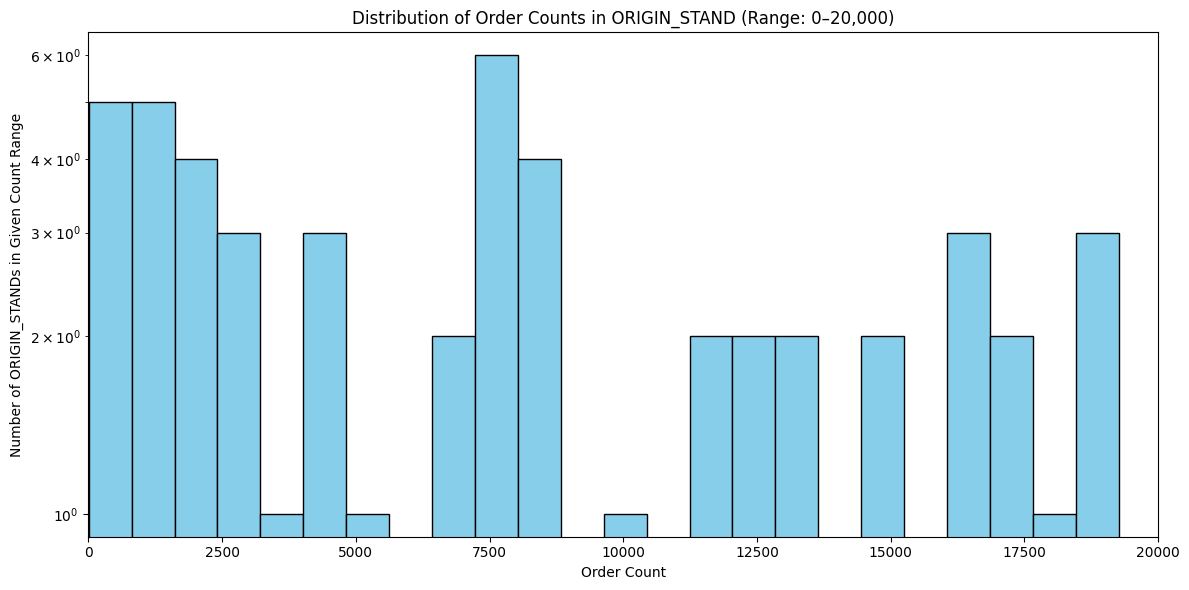

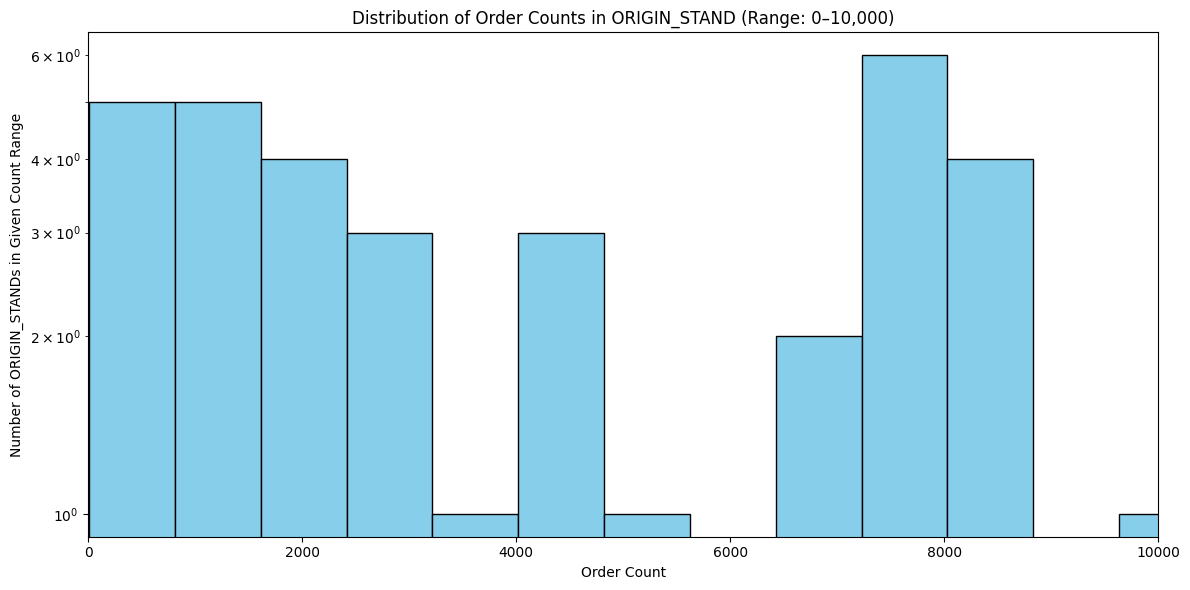

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the ORIGIN_STAND_statistics.csv file
file_path = r"ORIGIN_STAND_statistics.csv"

# Load data from the file
df = pd.read_csv(file_path)

# Draw histogram
plt.figure(figsize=(12, 6))
plt.hist(df['count'], bins=100, color='skyblue', edgecolor='black')

# Chart settings
plt.title("Distribution of Order Counts in ORIGIN_STAND")
plt.xlabel("Order Count")
plt.ylabel("Number of ORIGIN_STANDs in Given Count Range")
plt.yscale('log')

# Display the plot
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Path to the ORIGIN_STAND_statistics.csv file
file_path = r"ORIGIN_STAND_statistics.csv"

# Load data from the file
df = pd.read_csv(file_path)

# Draw histogram for the range 0–20,000
plt.figure(figsize=(12, 6))
plt.hist(df['count'], bins=100, color='skyblue', edgecolor='black')

# Set x-axis range to 0–20,000
plt.xlim(0, 20000)

# Chart settings
plt.title("Distribution of Order Counts in ORIGIN_STAND (Range: 0–20,000)")
plt.xlabel("Order Count")
plt.ylabel("Number of ORIGIN_STANDs in Given Count Range")
plt.yscale('log')

# Display the plot
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Path to the ORIGIN_STAND_statistics.csv file
file_path = r"ORIGIN_STAND_statistics.csv"

# Load data from the file
df = pd.read_csv(file_path)

# Draw histogram for the range 0–10,000
plt.figure(figsize=(12, 6))
plt.hist(df['count'], bins=100, color='skyblue', edgecolor='black')

# Set x-axis range to 0–10,000
plt.xlim(0, 10000)

# Chart settings
plt.title("Distribution of Order Counts in ORIGIN_STAND (Range: 0–10,000)")
plt.xlabel("Order Count")
plt.ylabel("Number of ORIGIN_STANDs in Given Count Range")
plt.yscale('log')

# Display the plot
plt.tight_layout()
plt.show()

script for analysis – analize_TAXI_ID.py

In [ ]:
import pandas as pd

# File paths
input_file_path = r"train_no_gaps.csv"
output_file_path = r"TAXI_ID_statistics.csv"

# Load data from train_no_gaps.csv
df = pd.read_csv(input_file_path)

# Remove records with NULL in the TAXI_ID column
df_filtered = df.dropna(subset=['TAXI_ID'])

# Group by TAXI_ID and count the number of occurrences
origin_call_counts = df_filtered['TAXI_ID'].value_counts().reset_index()
origin_call_counts.columns = ['TAXI_ID', 'count']

# Export results to TAXI_ID_statistics.csv
origin_call_counts.to_csv(output_file_path, index=False)

print("The file TAXI_ID_statistics.csv has been saved.")

The file TAXI_ID_statistics.csv has been saved.


script for table – table_TAXI_ID.py

In [ ]:
import pandas as pd

# Path to the statistics file
file_path = r"TAXI_ID_statistics.csv"

# Load the data
df = pd.read_csv(file_path)

# Calculate statistics
min_courses = df['count'].min()
max_courses = df['count'].max()
mean_courses = df['count'].mean()
median_courses = df['count'].median()
std_courses = df['count'].std()

# Create a DataFrame with the statistics
stats_df = pd.DataFrame({
    'Statistic': ['Minimum number of trips', 'Maximum number of trips', 'Average number of trips', 'Median number of trips', 'Standard deviation'],
    'Value': [min_courses, max_courses, mean_courses, median_courses, std_courses]
})

# Display the table
print(stats_df)

                 Statistic         Value
0  Minimum number of trips      1.000000
1  Maximum number of trips  10731.000000
2  Average number of trips   3793.232143
3   Median number of trips   3699.000000
4       Standard deviation   1637.294427


script for drawing chart – figure_TAXI_ID.py

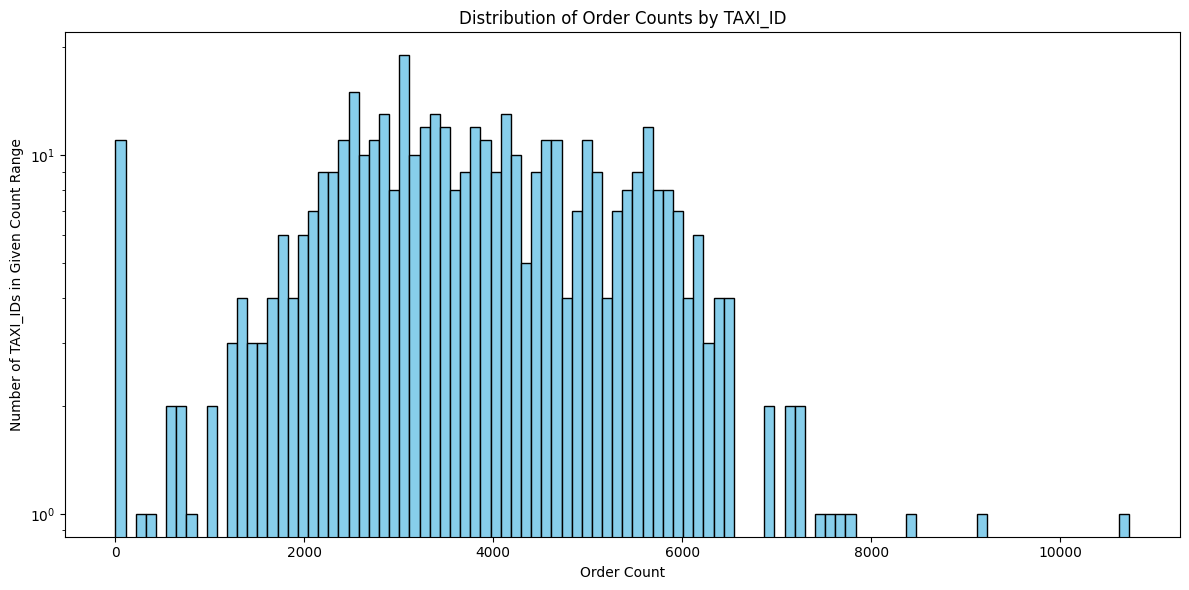

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the TAXI_ID_statistics.csv file
file_path = r"TAXI_ID_statistics.csv"

# Load data from the file
df = pd.read_csv(file_path)

# Draw histogram
plt.figure(figsize=(12, 6))
plt.hist(df['count'], bins=100, color='skyblue', edgecolor='black')  

# Plot settings
plt.title("Distribution of Order Counts by TAXI_ID")
plt.xlabel("Order Count")
plt.ylabel("Number of TAXI_IDs in Given Count Range")
plt.yscale('log')  

# Display the plot
plt.tight_layout()
plt.show()

script for converting UNIX TIMESTAMP to dates – TIMESTAMP_to_DATE.py

In [ ]:
import pandas as pd
import datetime

# Define file paths
input_file = r"train_no_gaps.csv"
output_file = r"DATE.csv"

# Load data from the CSV file
df = pd.read_csv(input_file)

# Define a function to convert Unix Timestamp to SQL date
def convert_to_sql_date(timestamp):
    return datetime.datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d')

# Apply the function to the TIMESTAMP column and create a new DATE column
df['DATE'] = df['TIMESTAMP'].apply(convert_to_sql_date)

# Select required columns and save to a new CSV file
df[['TRIP_ID', 'DATE']].to_csv(output_file, index=False)

print("Conversion completed successfully. See file:", output_file)

script for table and info – table_DATE.py

In [ ]:
import pandas as pd
import calendar

# Load data
df = pd.read_csv(r"DATE.csv")

# Convert the date column to datetime object
df['DATE'] = pd.to_datetime(df['DATE'])

# Group data by months and count trips
df_monthly = df.groupby(df['DATE'].dt.month)['TRIP_ID'].count().reset_index()
df_monthly.columns = ['Month', 'Number_of_trips']

# Calculate statistics
stats = df_monthly['Number_of_trips'].describe()

# Find the months with the minimum and maximum number of trips
min_month = df_monthly.loc[df_monthly['Number_of_trips'] == stats['min'], 'Month'].values[0]
max_month = df_monthly.loc[df_monthly['Number_of_trips'] == stats['max'], 'Month'].values[0]

# Find the month names for the minimum and maximum values
min_month_name = calendar.month_name[min_month]
max_month_name = calendar.month_name[max_month]

# Create the statistical table
table = pd.DataFrame({
    'Statistic': ['Minimum number of trips', 'Maximum number of trips', 'Average number of trips',
                  'Median', 'Standard deviation', 'Month with minimum number of trips', 'Month with maximum number of trips'],
    'Value': [stats['min'], stats['max'], stats['mean'], stats['50%'], stats['std'], min_month_name, max_month_name]
})

print(table)

                            Statistic         Value
0             Minimum number of trips      125196.0
1             Maximum number of trips      160629.0
2             Average number of trips      141614.0
3                              Median      141933.0
4                  Standard deviation  10696.313605
5  Month with minimum number of trips        August
6  Month with maximum number of trips           May


script for drawing chart – figure_DATE.py

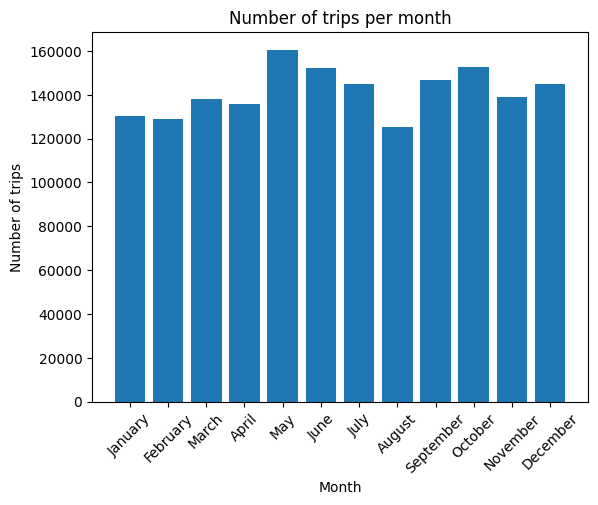

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r"DATE.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

# Group data by months and count trips
df_monthly = df.groupby(df['DATE'].dt.month)['TRIP_ID'].count().reset_index()
df_monthly.columns = ['Month', 'Number_of_trips']

# Convert month numbers to names
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df_monthly['Month'] = df_monthly['Month'].map(lambda x: months[x-1])

# Create a bar chart with month names
plt.bar(df_monthly['Month'], df_monthly['Number_of_trips'])
plt.xlabel('Month')
plt.ylabel('Number of trips')
plt.title('Number of trips per month')
plt.xticks(rotation=45)  # Rotate X-axis labels for better readability
plt.show()

script for analysis – analize_DAY_TYPE.py

In [ ]:
import pandas as pd

# Load data from CSV file
file_path = r'train_no_gaps.csv'
data = pd.read_csv(file_path)

# Check if the 'DAY_TYPE' column exists
if 'DAY_TYPE' in data.columns:
    # Calculate counts and percentages
    day_type_counts = data['DAY_TYPE'].value_counts()
    total_entries = len(data['DAY_TYPE'])
    day_type_percentage = (day_type_counts / total_entries) * 100

    # Create DataFrame with results
    analysis_results = pd.DataFrame({
        'Count': day_type_counts,
        'Percentage (%)': day_type_percentage
    }).reset_index().rename(columns={'index': 'DAY_TYPE'})

    # Display the results
    print(analysis_results)
else:
    print("The 'DAY_TYPE' column was not found in the file.")

  DAY_TYPE    Count  Percentage (%)
0        A  1699368           100.0


script for analysis – analize_MISSING_DATA.py

In [ ]:
import pandas as pd

# Load data from CSV file
file_path = r'train_no_gaps.csv'
data = pd.read_csv(file_path)

# Check if the 'MISSING_DATA' column exists
if 'MISSING_DATA' in data.columns:
    # Calculate counts and percentages
    missing_data_counts = data['MISSING_DATA'].value_counts()
    total_entries = len(data['MISSING_DATA'])
    missing_data_percentage = (missing_data_counts / total_entries) * 100

    # Create DataFrame with results
    analysis_results = pd.DataFrame({
        'Count': missing_data_counts,
        'Percentage (%)': missing_data_percentage
    }).reset_index().rename(columns={'index': 'MISSING_DATA'})

    # Display the results
    print(analysis_results)
else:
    print("The 'MISSING_DATA' column was not found in the file.")

   MISSING_DATA    Count  Percentage (%)
0         False  1699358       99.999412
1          True       10        0.000588


script for analysis – analize_POLYLINE.py

In [ ]:
import pandas as pd
import ast  # For converting string representations of lists into actual lists

# File path
file_path = r'train_no_gaps.csv'

# Load data with the specific columns: TRIP_ID and POLYLINE
data = pd.read_csv(file_path, usecols=['TRIP_ID', 'POLYLINE'])

# Function to count points in the POLYLINE column
def count_points(polyline):
    try:
        points = ast.literal_eval(polyline)  # Convert string to list
        return len(points)  # Return the number of points
    except (ValueError, SyntaxError):
        return 0  # Return 0 if POLYLINE is empty or invalid

# Create a new column with the number of points
data['count'] = data['POLYLINE'].apply(count_points)

# Create a new DataFrame with TRIP_ID and count columns
polyline_statistics = data[['TRIP_ID', 'count']]

# Output file path
output_path = r'POLYLINE_statistics.csv'

# Export to CSV
polyline_statistics.to_csv(output_path, index=False)

print(f"Results have been saved to the file: {output_path}")

script for table – table_POLYLINE.py

In [ ]:
import pandas as pd

# File path to POLYLINE_statistics
file_path = r'POLYLINE_statistics.csv'

# Load data
data = pd.read_csv(file_path)

# Convert the number of points to trip duration (in minutes; 1 point = 15 seconds)
data['trip_duration_minutes'] = data['count'] * 15 / 60

# Statistical calculations
min_duration = data['trip_duration_minutes'].min()            # Shortest trip
max_duration = data['trip_duration_minutes'].max()            # Longest trip
mean_duration = data['trip_duration_minutes'].mean()          # Average trip duration
median_duration = data['trip_duration_minutes'].median()      # Median trip duration
std_duration = data['trip_duration_minutes'].std()            # Standard deviation of trip duration

# Create a summary table
summary = pd.DataFrame({
    'Statistic': [
        'Shortest trip (min)',
        'Longest trip (min)',
        'Average trip duration (min)',
        'Median trip duration (min)',
        'Standard deviation (min)'
    ],
    'Value': [
        min_duration,
        max_duration,
        mean_duration,
        median_duration,
        std_duration
    ]
})

# Display the summary table
print("Trip duration analysis (in minutes):")
print(summary)

Trip duration analysis (in minutes):
                     Statistic       Value
0          Shortest trip (min)    0.000000
1           Longest trip (min)  970.250000
2  Average trip duration (min)   12.184985
3   Median trip duration (min)   10.250000
4     Standard deviation (min)   11.421451


script for drawing chart – figure_POLYLINE.py

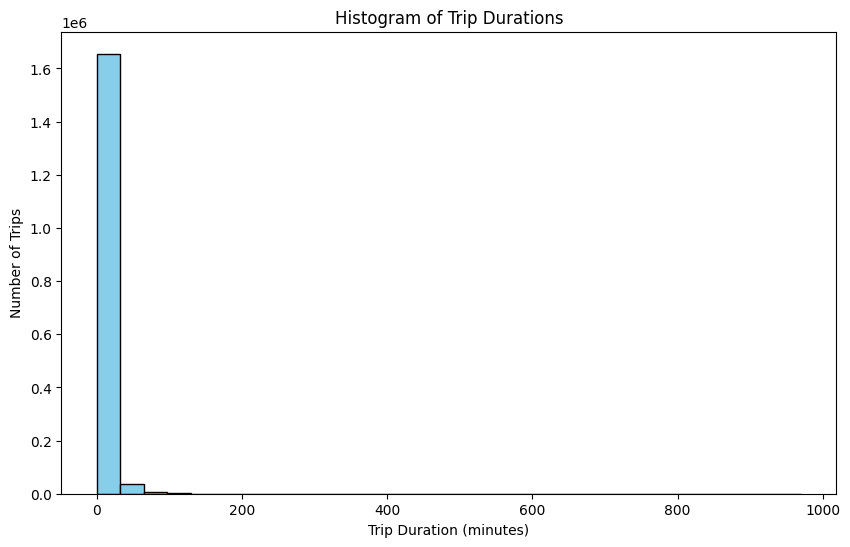

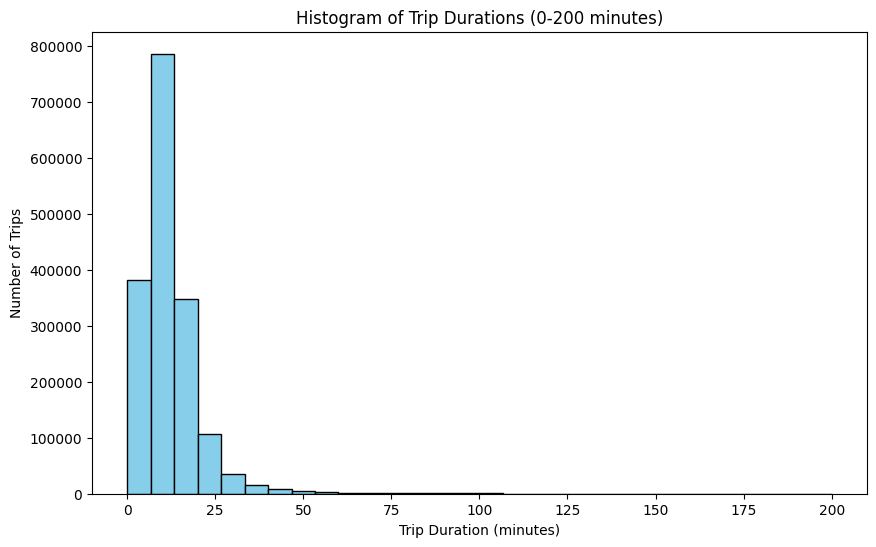

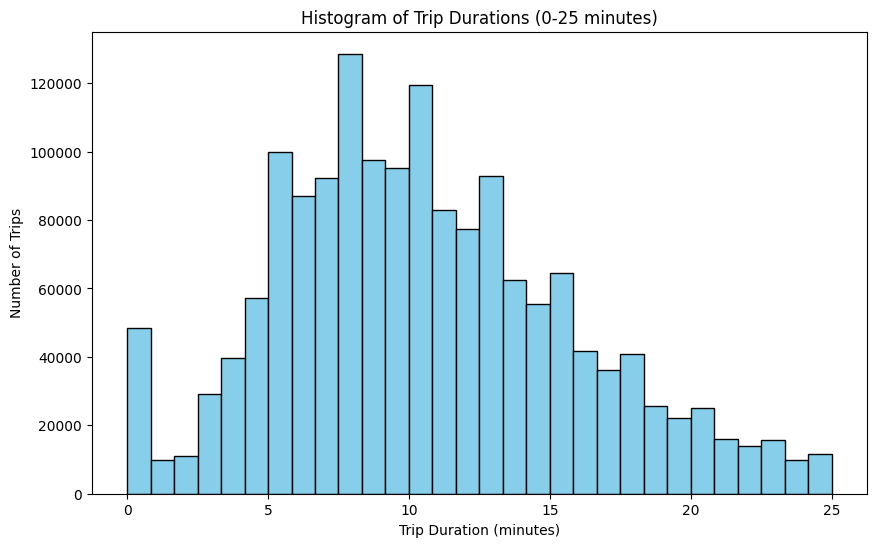

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the POLYLINE_statistics file
file_path = r'POLYLINE_statistics.csv'

# Loading data
data = pd.read_csv(file_path)

# Converting the number of points to trip duration in minutes
data['trip_duration_minutes'] = data['count'] * 15 / 60

# Creating a histogram
plt.figure(figsize=(10, 6))
plt.hist(data['trip_duration_minutes'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.title('Histogram of Trip Durations')

# Display the histogram
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Path to the POLYLINE_statistics file
file_path = r'POLYLINE_statistics.csv'

# Loading data
data = pd.read_csv(file_path)

# Converting the number of points to trip duration in minutes
data['trip_duration_minutes'] = data['count'] * 15 / 60

# Filtering data for the 0-200 minute range
filtered_data = data[(data['trip_duration_minutes'] >= 0) & (data['trip_duration_minutes'] <= 200)]

# Creating a histogram for the 0-200 minute range
plt.figure(figsize=(10, 6))
plt.hist(filtered_data['trip_duration_minutes'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.title('Histogram of Trip Durations (0-200 minutes)')

# Display the histogram
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Path to the POLYLINE_statistics file
file_path = r'POLYLINE_statistics.csv'

# Loading data
data = pd.read_csv(file_path)

# Converting the number of points to trip duration in minutes
data['trip_duration_minutes'] = data['count'] * 15 / 60

# Filtering data for the 0-25 minute range
filtered_data = data[(data['trip_duration_minutes'] >= 0) & (data['trip_duration_minutes'] <= 25)]

# Creating a histogram for the 0-25 minute range
plt.figure(figsize=(10, 6))
plt.hist(filtered_data['trip_duration_minutes'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.title('Histogram of Trip Durations (0-25 minutes)')

# Display the histogram
plt.show()

true_for_POLYLINE.py 

In [ ]:
import pandas as pd

# Loading data from the CSV file
file_path = r"train_no_gaps.csv"
data = pd.read_csv(file_path)

# Filtering the data to find POLYLINE where MISSING_DATA = true
missing_data_polyline = data[data['MISSING_DATA'] == True]['POLYLINE']

# Displaying the results
print("POLYLINE where MISSING_DATA = true:")
print(missing_data_polyline)

# Displaying the number of records
print(f"Number of POLYLINE where MISSING_DATA = true: {len(missing_data_polyline)}")

POLYLINE where MISSING_DATA = true:
104978     [[-8.612559,41.145975],[-8.612577,41.145975],[...
170468                               [[-0.205893,41.010282]]
297623     [[-8.569719,41.166135],[-8.567928,41.166477],[...
455062     [[-8.626347,41.153436],[-8.626275,41.152905],[...
734319     [[-8.652816,40.636575],[-8.652807,40.636566],[...
777864     [[-8.604558,41.161941],[-8.604477,41.162013],[...
843506     [[-8.609697,41.160276],[-8.609571,41.16033],[-...
926731     [[-8.604792,41.16123],[-8.604801,41.161167],[-...
1267955                             [[-10.634022,43.834248]]
1423083    [[-8.620011,41.14683],[-8.619957,41.146659],[-...
Name: POLYLINE, dtype: object
Number of POLYLINE where MISSING_DATA = true: 10


0_counter_POLYLINE.py

In [ ]:
import pandas as pd

# Loading data from the CSV file
file_path = r"POLYLINE_statistics.csv"
data = pd.read_csv(file_path)

# Filtering the data to find TRIP_ID where count = 0
result = data[data['count'] == 0]['TRIP_ID']

# Displaying the results
print("TRIP_ID where count = 0:")
print(result)

# Displaying the number of records
print(f"Number of TRIP_ID where count = 0: {len(result)}")

TRIP_ID where count = 0:
757        1372665673620000353
1155       1372669158620000562
1448       1372665875620000496
1663       1372667320620000288
1705       1372676112620000600
                  ...         
1699247    1403120685620000226
1699342    1386603894620000970
1699356    1373986578620000931
1699362    1390403767620000911
1699365    1388745716620000264
Name: TRIP_ID, Length: 5881, dtype: int64
Number of TRIP_ID where count = 0: 5881


### SCRIPT FOR CORRELATION ANALYSIS

correlation_matrix.py

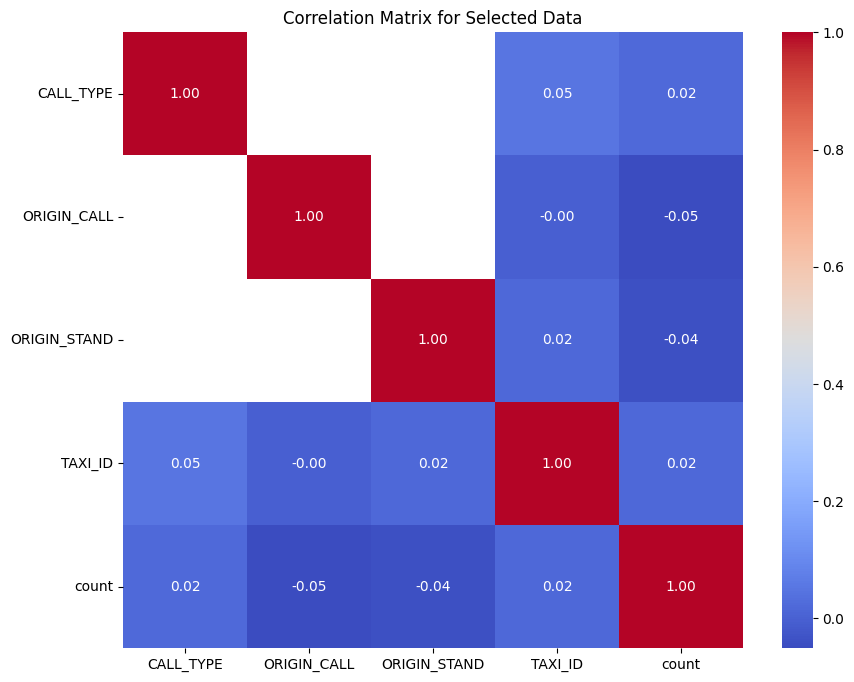

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading data
train_data = pd.read_csv(r'train_no_gaps.csv')
polyline_stats = pd.read_csv(r'POLYLINE_statistics.csv')

# Mapping CALL_TYPE
train_data['CALL_TYPE'] = train_data['CALL_TYPE'].map({'A': 0, 'B': 1, 'C': 2})

# Adding the 'count' column from POLYLINE_statistics.csv based on TRIP_ID
train_data = train_data.merge(polyline_stats[['TRIP_ID', 'count']], on='TRIP_ID', how='inner')

# Removing columns that are not needed
columns_to_drop = ['TRIP_ID', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE', 'TIMESTAMP']
train_data = train_data.drop(columns=columns_to_drop)

# Calculating the correlation matrix
correlation_matrix = train_data.corr()

# Heatmap plot
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)

# Rotating the Y-axis labels (variable names) by 0 degrees so they are horizontal
plt.yticks(rotation=0)

# Setting the title of the plot
plt.title("Correlation Matrix for Selected Data")

# Displaying the plot
plt.show()

## SCRIPTS FOR DATA CLEANING

cleaning_data_1.py 

In [ ]:
import pandas as pd

# Load data from the file train.csv
data = pd.read_csv(r"train.csv")

# Remove records where TRIP_ID is missing
cleaned_data = data.dropna(subset=['TRIP_ID'])

# Remove records where CALL_TYPE is missing
cleaned_data = cleaned_data.dropna(subset=['CALL_TYPE'])

# Remove records where TAXI_ID is missing
cleaned_data = cleaned_data.dropna(subset=['TAXI_ID'])

# Remove records where TIMESTAMP is missing
cleaned_data = cleaned_data.dropna(subset=['TIMESTAMP'])

# Remove records where MISSING_DATA is TRUE or missing values exist
cleaned_data = cleaned_data[~(cleaned_data['MISSING_DATA'] == True)]
cleaned_data = cleaned_data.dropna(subset=['MISSING_DATA'])

# Remove records where POLYLINE contains '[]'
cleaned_data = cleaned_data[cleaned_data['POLYLINE'] != '[]']

# Remove the DAY_TYPE column as all values are the same
cleaned_data = cleaned_data.drop(columns=['DAY_TYPE'])

# Save the cleaned data to cleaning_data_step_1.csv
cleaned_data.to_csv(r"cleaning_data_step_1.csv", index=False)

cleaning_data_2.py 

In [ ]:
import pandas as pd

# Load data from the file cleaning_data_step_1.csv
cleaned_data = pd.read_csv(r"cleaning_data_step_1.csv")

# Remove the MISSING_DATA column
cleaned_data = cleaned_data.drop(columns=['MISSING_DATA'])

# Save the cleaned data to cleaning_data_step_2.csv
cleaned_data.to_csv(r"cleaning_data_step_2.csv", index=False)

cleaning_data_3.py 

In [ ]:
import pandas as pd

# Load data from the file cleaning_data_step_2.csv
cleaned_data = pd.read_csv(r"cleaning_data_step_2.csv")

# Remove duplicates in TRIP_ID
cleaned_data = cleaned_data.drop_duplicates(subset=['TRIP_ID'])

# Save the cleaned data to cleaning_data_step_3.csv
cleaned_data.to_csv(r"cleaning_data_step_3.csv", index=False)

cleaning_data_4.py 

In [ ]:
import pandas as pd

# Load data from the file cleaning_data_step_3.csv
cleaned_data = pd.read_csv(r"cleaning_data_step_3.csv")

# Map CALL_TYPE: 'A' -> 0, 'B' -> 1, 'C' -> 2
call_type_mapping = {'A': 0, 'B': 1, 'C': 2}
cleaned_data['CALL_TYPE'] = cleaned_data['CALL_TYPE'].map(call_type_mapping)

# Save to the file cleaning_data_step_4.csv
cleaned_data.to_csv(r"cleaning_data_step_4.csv", index=False)

cleaning_data_5.py 

In [ ]:
import pandas as pd

# Load data from the file cleaning_data_step_4.csv
cleaned_data = pd.read_csv(r"cleaning_data_step_4.csv")

# Special conditions for ORIGIN_CALL and ORIGIN_STAND

# If CALL_TYPE == '0' and ORIGIN_CALL is NULL, remove the record
cleaned_data = cleaned_data[~((cleaned_data['CALL_TYPE'] == 0) & (cleaned_data['ORIGIN_CALL'].isna()))]

# If CALL_TYPE == '1' and ORIGIN_STAND is NULL, remove the record
cleaned_data = cleaned_data[~((cleaned_data['CALL_TYPE'] == 1) & (cleaned_data['ORIGIN_STAND'].isna()))]

# Save to the file cleaning_data_step_5.csv
cleaned_data.to_csv(r"cleaning_data_step_5.csv", index=False)